In [40]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

### **Ejercicio N°2**

Lea en *Colab* el archivo `incendios-cantidad-causas-provincia_2022.csv` y realice cualquier tarea de limpieza y/o adecuación del dataset que considere necesaria.

1. Obtenga el número de incendios totales por año **para todo el país**. ¿Cuál fue el año en el que se presentó un mayor número de incendios?
2. Obtenga el número de incendios totales por año para el período 1993-2021 **en la provincia de Córdoba**.
3. Realice una tabla en la que se muestre, para cada año del periodo 1993-2021, la provincia en la que tuvo lugar el mayor número de incendios intencionales. *Sugerencia:* explore las funcionalidades del método `idxmax()` de la librería Pandas.
4. Realice un gráfico de barras para visualizar el número de incendios intencionales, por negligencia y naturales que tuvieron lugar durante el periodo 2015-2021 en la provincia de Santa Fe.
5. Obtenga el número promedio de incendios intencionales, por negligencia y naturales para la provincia de Río Negro durante el periodo 1993-2021.

In [41]:
incendios = pd.read_csv('./datasets/incendios-cantidad-causas-provincia_2022.csv', encoding='latin1', header=3)

In [42]:
incendios.head()

,anio,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Buenos Aires,0,0,0,0,0
1,1993,Catamarca,0,0,0,0,0
2,1993,Chaco,0,0,0,0,0
3,1993,Chubut,21,18,0,0,3
4,1993,Córdoba,151,0,0,0,151


In [43]:
incendios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   anio         676 non-null    int64 
 1   provincia    676 non-null    object
 2   total        676 non-null    int64 
 3   negligencia  676 non-null    int64 
 4   intencional  676 non-null    int64 
 5   natural      676 non-null    object
 6   desconocida  676 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 37.1+ KB


In [44]:
incendios['natural'].unique()

array(['0', '3', '1', '2', '67', '24', '-', '8', '22', '11', '7', '27',
       '176', '63', '4', '5', '37', '26', '15', '836', '16', '12', '20',
       '642', '40', '10', '51', '188', '13', '50', '9', '294', '128',
       '47', '222', '121', '400', '31', '33', '44', '45', '101', '373',
       '6', '38', '56', '148', '309', '17', '14', '34', '71', '547', '66',
       '18', '85', '68', '302', '19', '60', '48', '57', '249', '52', '32',
       '706', '49', '96', '28', '91', '30', '591', '54', '43', '46', '58',
       '92', '59', '39', '61', '114', '441', '21', '100', '89'],
      dtype=object)

In [45]:
incendios['natural']=incendios['natural'].str.replace('-','0')
incendios['natural']=incendios['natural'].astype(int)
incendios['provincia']=incendios['provincia'].str.strip()
incendios['provincia'].sort_values().unique()
incendios['provincia']=incendios['provincia'].replace({'Cordoba':'Córdoba'})

In [46]:
incendios.isnull().sum()

anio           0
provincia      0
total          0
negligencia    0
intencional    0
natural        0
desconocida    0
dtype: int64

### Obtenga el número de incendios totales por año para todo el país. ¿Cuál fue el año en el que se presentó un mayor número de incendios?

In [47]:
incendios_anual=incendios.groupby('anio')['total'].sum().sort_values(ascending=False)

In [48]:
incendios_anual2=incendios.groupby('anio')[['negligencia','intencional']].sum()
incendios_anual2

,negligencia,intencional
anio,,
1993,77,4
1994,577,15
1995,3368,272
1996,1429,1858
1997,1969,1094
1998,4167,1544
1999,4124,2265
2000,3519,2136
2001,2420,1258


In [49]:
incendios_anual.tail()

anio
1997    4660
1995    4145
1996    4057
1994     852
1993     538
Name: total, dtype: int64

### Obtenga el número de incendios totales por año para el período 1993-2021 en la provincia de Córdoba.


In [50]:
incen_cba=incendios[incendios['provincia']=='Córdoba']
incen_cba.head()

,anio,provincia,total,negligencia,intencional,natural,desconocida
4,1993,Córdoba,151,0,0,0,151
27,1994,Córdoba,161,158,0,3,0
50,1995,Córdoba,2441,2441,0,0,0
73,1996,Córdoba,92,0,0,0,92
95,1997,Córdoba,387,35,121,0,231


In [51]:
incen_cba_anual=incen_cba.groupby('anio')['total'].sum().sort_values(ascending=False)

In [52]:
incen_cba_anual.head()

anio
1995    2441
2000     869
2005     763
2006     438
1997     387
Name: total, dtype: int64

### Realice una tabla en la que se muestre, para cada año del periodo 1993-2021, la provincia en la que tuvo lugar el mayor número de incendios intencionales. 
### Sugerencia: explore las funcionalidades del método idxmax() de la librería Pandas.

In [53]:
max=incendios.idxmax()
max

anio           652
provincia       22
total          348
negligencia    114
intencional     70
natural        114
desconocida    348
dtype: int64

In [54]:
max_intencional=incendios.iloc[70]
max_intencional

anio                1996
provincia      Catamarca
total               1732
negligencia            0
intencional         1662
natural                0
desconocida           70
Name: 70, dtype: object

In [55]:
indices_maximos = incendios.groupby('anio')['intencional'].idxmax()
indices_maximos.head()

anio
1993     21
1994     37
1995     60
1996     70
1997    105
Name: intencional, dtype: int64

In [56]:
resultado = incendios.loc[indices_maximos, ['anio', 'provincia', 'intencional']]
resultado.head()

,anio,provincia,intencional
21,1993,Tierra del Fuego,2
37,1994,Río Negro,7
60,1995,Río Negro,250
70,1996,Catamarca,1662
105,1997,Río Negro,453


In [57]:
resultado = resultado.reset_index(drop=True)
resultado.head()

,anio,provincia,intencional
0,1993,Tierra del Fuego,2
1,1994,Río Negro,7
2,1995,Río Negro,250
3,1996,Catamarca,1662
4,1997,Río Negro,453


### Realice un gráfico de barras para visualizar el número de incendios intencionales, por negligencia y naturales que tuvieron lugar durante el periodo 2015-2021 en la provincia de Santa Fe.

In [58]:
df_periodo=incendios[(incendios['anio'] >= 2015) & (incendios['anio'] <= 2021)]
sta_fe=df_periodo[df_periodo['provincia']=='Santa Fe']
sta_fe=sta_fe.reset_index(drop=True)
sta_fe.head()

,anio,provincia,total,negligencia,intencional,natural,desconocida
0,2015,Santa Fe,1047,307,592,3,145
1,2016,Santa Fe,1241,252,702,0,287
2,2017,Santa Fe,1096,247,596,15,238
3,2018,Santa Fe,1691,308,1131,2,250
4,2019,Santa Fe,1251,151,804,2,294


In [59]:
sta_fe2=sta_fe.set_index('anio')[['intencional', 'negligencia','natural']]
sta_fe2.head()

,intencional,negligencia,natural
anio,,,
2015,592,307,3
2016,702,252,0
2017,596,247,15
2018,1131,308,2
2019,804,151,2


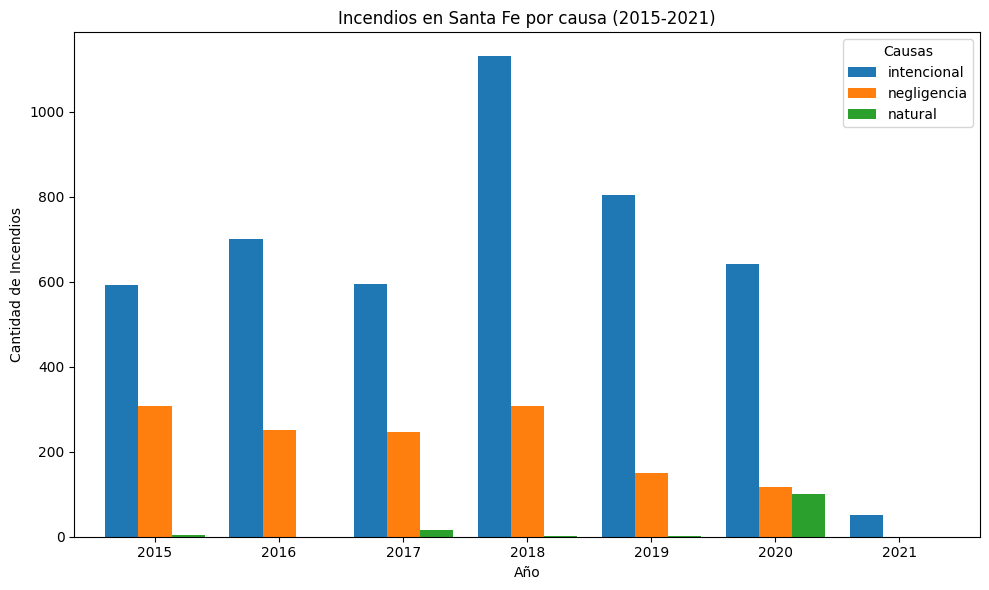

In [60]:
# Agregamos logy=True para cambiar la escala del eje Y
sta_fe2.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Incendios en Santa Fe por causa (2015-2021)')
plt.xlabel('Año')
plt.ylabel('Cantidad de Incendios')
plt.xticks(rotation=0)  # Esto pone los años en horizontal para que se lean bien
plt.legend(title='Causas')
plt.tight_layout()      # Ajusta los márgenes automáticamente

# Mostrar el gráfico en pantalla
plt.show()

### Obtenga el número promedio de incendios intencionales, por negligencia y naturales para la provincia de Río Negro durante el periodo 1993-2021.

In [61]:
rio_negro=incendios[(incendios['anio'] >= 1993) & (incendios['anio'] <= 2021)&(incendios['provincia']=='Río Negro')]
rio_negro=rio_negro.reset_index(drop=True)
rio_negro.head()

,anio,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Río Negro,36,36,0,0,0
1,1994,Río Negro,258,251,7,0,0
2,1995,Río Negro,418,168,250,0,0
3,1996,Río Negro,361,73,11,27,250
4,1997,Río Negro,700,245,453,2,0


In [62]:
#reemplazo los - por 0
rio_negro['natural']=pd.to_numeric(rio_negro['natural'].replace('-',0))
rio_negro.head(10)

,anio,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Río Negro,36,36,0,0,0
1,1994,Río Negro,258,251,7,0,0
2,1995,Río Negro,418,168,250,0,0
3,1996,Río Negro,361,73,11,27,250
4,1997,Río Negro,700,245,453,2,0
5,1998,Río Negro,1197,185,520,26,466
6,1999,Río Negro,902,518,118,8,258
7,2000,Río Negro,1143,741,144,24,234
8,2001,Río Negro,1836,542,161,222,911
9,2002,Río Negro,1952,510,97,63,1282


In [63]:
promedios = rio_negro[['intencional', 'negligencia', 'natural']].mean()
print("Promedio de incendios en Río Negro (1993-2021):")
print(promedios)

Promedio de incendios en Río Negro (1993-2021):
intencional    343.758621
negligencia    240.965517
natural         18.896552
dtype: float64
